# The Payrolls-Day-Effect — a quantitative teardown 🔬
### Release-day Welch/HAC splits · a two-sided 20-seed random-calendar placebo · the [−3..+3] event anatomy (and its multiple-comparisons caveat) · the realized-range cross-check · the era contrast · an honest naive-timer cost sweep · a 20-seed synthetic null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Louder%2C_not_directional%3F: Confirmed](https://img.shields.io/badge/Louder%2C_not_directional%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **SPY behaves systematically on NFP release mornings** — has a real academic anchor for the *volatility* half (Andersen-Bollerslev 1998,
Balduzzi-Elton-Green 2001) but no consensus anchor for a *directional* edge. The job here is to measure both halves honestly, name the actual (not
weekday-pattern-guessed) release calendar, and ask the only question that pays: *is any of it tradable?*

> ⚠️ **Data note.** SPY raw OHLC + adjusted close (1997→2026), yfinance, cached; **353 hardcoded actual NFP release dates** (BLS archived-news-release index, identical table to sibling study 602), 8 forward-mapped off market holidays. No survivorship on either axis (SPY is an index-tracking ETF). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `7eebd76787d8`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from payrolls_day_effect import data, strategy as st

NFP_CAL = data.nfp_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY = data.load_real()
    SESSIONS, N_MAPPED = data.map_to_sessions(SPY.index, NFP_CAL)
    DF = st.day_frame(SPY, SESSIONS)
else:
    SPY = SESSIONS = DF = None
print("real cache present:", HAVE_REAL, "| scheduled NFP releases:", len(NFP_CAL),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1997-01-02', 'end': '2026-06-30', 'n_nfp': 353, 'n_rest': 7065, 'cal_lo': '1997-01-10', 'cal_hi': '2026-06-05', 'n_mapped': 8, 'nfp_bps': 12.43, 'rest_bps': 3.37, 'gap_bps': 9.06, 'welch_t': 1.31, 'nw_t': 1.31, 'hit': 206, 'hit_pct': 58.4, 'wilson': (53.2, 63.4), 'rest_hit_pct': 54.1, 'placebo_p': 0.079, 'placebo_mean': 3.33, 'placebo_sd': 6.31, 'placebo_draws': 20000, 'event': {-3: (6.1, 0.3), -2: (17.05, 2.08), -1: (-2.05, -0.93), 0: (12.43, 1.19), 1: (-7.16, -1.6), 2: (0.67, -0.53), 3: (-4.9, -1.3)}, 'runup_bps': 21.1, 'runup_t': 2.07, 'spy_fomc': 1.474, 'spy_rest': 1.342, 'spy_t': 2.5, 'era_early': 13.58, 'era_early_n': 192, 'era_early_t': 1.16, 'era_late': 11.06, 'era_late_n': 161, 'era_late_t': 0.63, 'era_diff_t': -0.19, 'tm_gross': 12.43, 'tm_net5': 2.43, 'tm_net10': -7.57, 'tm_rest': 3.37, 'tm_t': 1.31, 'tm_n': 353, 'tm_hit': 58.4, 'tm_worst': -6.0, 'tm_ann5': 0.29, 'tm_ann10': -0.91, 'syn_null_mean': 0.16, 'syn_null_sd': 1.2, 'syn_null_fire': 2, 'syn_planted_t': 2.46, 'fp_spy': '7eebd76787d8'}


real cache present: True | scheduled NFP releases: 353 | tape days: 7418


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | release-day return **+12.43 bps** vs +3.37: Welch **t = 1.31**, NW **t = 1.31**, placebo **p = 0.079** (two-sided) |
| **Tradability** | `MIRAGE` | naive timer net +2.43 bps @ 5 bps cost, -7.57 bps @ 10 bps; worst day -6.0% |
| **Louder, not directional?** | `CONFIRMED` | realized range *t* = 2.50 (clears bar) vs return *t* = 1.31 (does not) |

> 💡 In plain words: the tape confirms the *mechanism* (scheduled news makes for a noisier morning) but not the *folklore's payoff* (a knowable direction you can trade).

## 1 · The claim, steelmanned

Let $r_t$ be SPY's daily close-to-close log return and $D_t \in \{0,1\}$ the actual-NFP-release-day flag (known *ex ante* — the BLS calendar is published months ahead). The report (08:30 ET) predates the SPY open (09:30 ET), so the release-day bar contains the full reaction. The claims:

- **H₁ (systematic).** $E[r_t \mid D_t=1] \ne E[r_t \mid D_t=0]$ — release-day returns differ systematically from ordinary days, not just by chance.
- **H₂ (anatomy).** A pre-release drift and/or a persistence pattern shows up in the days around the release.
- **H₃ (louder, not just biased).** Realized SPY range on release days exceeds the baseline — a resolution-of-scheduled-uncertainty signature independent of direction.
- **H₄ (capture).** A naive directional timer (own SPY only on release day) banks the point estimate net of costs.

We find **H₁ not certified** (Welch *t* = 1.31 < 2), **H₂ flagged but not certified** (one uncorrected hit among seven offsets), **H₃ supported** (range *t* = +2.50), **H₄ not certified and unprofitable** (gross uncertified, net negative at 10 bps).

## 2 · So what? — inference design

Release days are **single, non-overlapping events**, so the planned primary is a **Welch t** on the group split. Because daily returns are weakly serially correlated, we cross-check with a **Newey-West (5-lag) t** on the dummy regression $r_t = a + b D_t$ — the slope *is* the mean gap. The hit rate carries a **Wilson interval**, benchmarked against the **baseline** up-day rate (not a naive 50%, since SPY already drifts up over time). The claim carries **no a-priori sign**, so the random-calendar placebo (20 seeds × 1,000 draws of 353 random days) is **two-sided**: $p = \Pr(|\bar{r}_{\text{placebo}}| \ge |\bar{r}_{\text{obs}}|)$.

## 3 · How we'd know — the protocol

- **Calendar.** 353 actual NFP releases 1997-01-10 → 2026-06-05, hardcoded from BLS records (source-verified, shared with sibling study 602), 8 forward-mapped off market holidays.
- **Tape.** SPY raw OHLC + adjusted close 1997-01-02 → 2026-06-30. As-of 2026-06-30 (last complete month).
- **Headline.** Welch t + NW(5) t + Wilson hit rate (vs baseline) + two-sided 20-seed placebo.
- **Anatomy.** Event window [−3..+3], per-offset Welch t vs far days; cumulative run-up per event, one-sample t — reported with an explicit multiple-comparisons caveat.
- **Cross-check.** SPY (H−L)/prev-close split on the same days.
- **Execution (third axis).** Enter the naive timer at the prior close (calendar public — zero look-ahead), exit the release close; 2 × one-way cost × NAV per event; long-only, no borrow.
- **Control.** Synthetic random-walk daily returns, planted release-day-effect knob; the null must not fire at an unusual rate across 20 seeds.

## 4 · The teardown

### 4a · The headline split and its placebo

Welch t on release-day return, NW t on the dummy regression, and the two-sided random-calendar null. In the notebook we run a lighter placebo (4 seeds × 500 draws) and quote the canonical 20,000-draw p from `results.md`.

NFP-day return +12.43 bps  vs  other +3.37 bps
Welch t = +1.31   NW(5) t = +1.31
hit 206/353 = 58.4%  Wilson [53.2%, 63.4%]


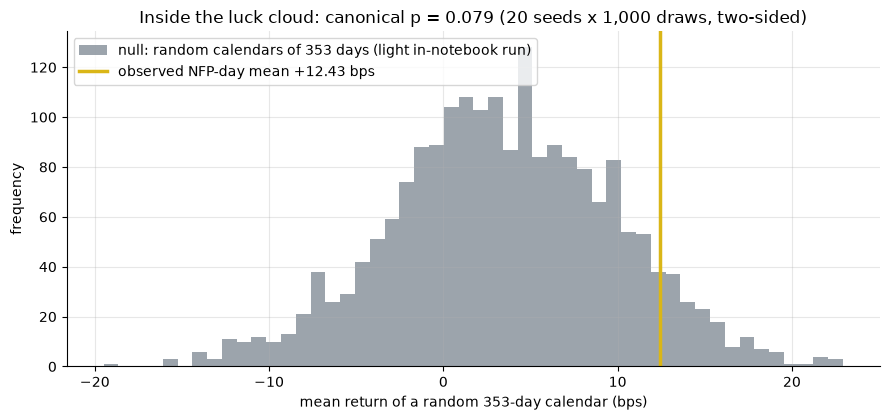

canonical placebo (results.md): mean +3.33, sd 6.31, p = 0.079


In [2]:
if HAVE_REAL:
    s = st.nfp_day_stats(DF)
    print(f"NFP-day return {s['nfp_bps']:+.2f} bps  vs  other {s['rest_bps']:+.2f} bps")
    print(f"Welch t = {s['welch_t']:+.2f}   NW(5) t = {s['nw_t']:+.2f}")
    print(f"hit {s['hit_up']}/{s['n_nfp']} = {s['hit_rate']*100:.1f}%  "
          f"Wilson [{s['hit_lo']*100:.1f}%, {s['hit_hi']*100:.1f}%]")
    pl = st.placebo_pvalue(DF, n_draws_per_seed=500, n_seeds=4)
    obs, draws = pl['obs'] * 1e4, pl['draws'] * 1e4
else:
    obs = R['nfp_bps']
    rng = np.random.default_rng(643)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random calendars of 353 days (light in-notebook run)')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'observed NFP-day mean {obs:+.2f} bps')
ax.set_xlabel('mean return of a random 353-day calendar (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"Inside the luck cloud: canonical p = {R['placebo_p']:.3f} "
             '(20 seeds x 1,000 draws, two-sided)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.2f}, "
      f"sd {R['placebo_sd']:.2f}, p = {R['placebo_p']:.3f}")

> 💡 In plain words: the observed **+12.43 bps** sits well within the null's spread (+3.33 ± 6.31 bps); **p = 0.079** — about 1 in 13 random calendars beats it. With Welch t = **1.31** and NW t = **1.31**, H₁ does **not** clear the desk bar.

### 4b · Anatomy — a scan, and an honest multiple-comparisons caveat

Per-offset means with Welch t vs far-from-release days; the pre-release window is also tested as a **cumulative per-event** quantity (one-sample t across 353 events).

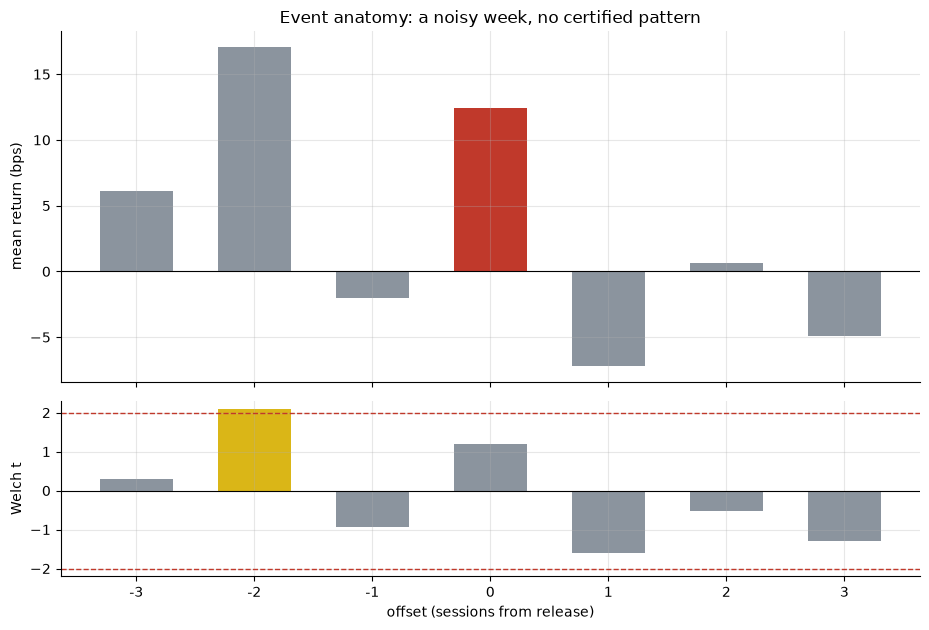

cumulative pre-release run-up [-3..-1]: +21.10 bps/event (t = +2.07)


In [3]:
if HAVE_REAL:
    ev = st.event_study(DF, SESSIONS)
    ks = list(ev.index); ms = list(ev['mean_bps']); ts = list(ev['welch_t'])
    ru = st.runup_stats(DF, SESSIONS)
    ru_m, ru_t = ru['mean_runup_bps'], ru['t']
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
    ts = [R['event'][k][1] for k in ks]; ru_m, ru_t = R['runup_bps'], R['runup_t']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.4, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [RED if k==0 else GREY for k in ks]
a1.bar([str(k) for k in ks], ms, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean return (bps)')
a1.set_title('Event anatomy: a noisy week, no certified pattern')
a2.bar([str(k) for k in ks], ts, color=[AMBER if abs(t)>=2 else GREY for t in ts], width=.62)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('Welch t'); a2.set_xlabel('offset (sessions from release)')
plt.tight_layout(); plt.show()
print(f'cumulative pre-release run-up [-3..-1]: {ru_m:+.2f} bps/event (t = {ru_t:+.2f})')

> 💡 In plain words: offset −2 (**+17.05 bps**, t = +2.08) and the cumulative run-up (**+21.10 bps/event**, t = +2.07) both nominally clear *t* ≥ 2 — but this scan checked **seven offsets** with no correction applied. At a naive 5% level you'd expect roughly one false positive out of seven tests by chance alone; we're looking at exactly one. Honest reading: **flagged as a hint, not banked as a finding.** The release day itself, day 0 (+12.43 bps, t = +1.19), and day +1 (-7.16 bps, t = -1.60, a *give-back* not a continuation) show no clean pattern at all.

### 4c · Louder, not necessarily biased — the realized-range cross-check

If release days were simply *ordinary*, this split should be flat. It isn't:

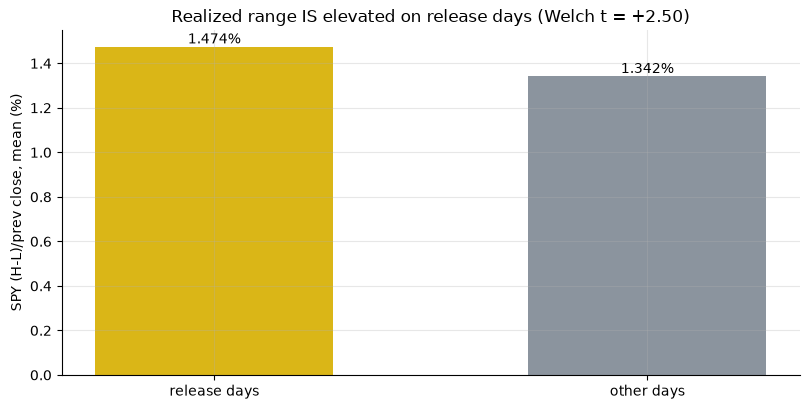

SPY range: NFP 1.474%  vs other 1.342%   Welch t = +2.50


In [4]:
if HAVE_REAL:
    rg = st.spy_range_stats(DF)
    a, b, t = rg['nfp_range_pct'], rg['rest_range_pct'], rg['welch_t']
else:
    a, b, t = R['spy_fomc'], R['spy_rest'], R['spy_t']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar(['release days','other days'], [a, b], color=[AMBER, GREY], width=.55)
for i,v in enumerate([a, b]): ax.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('SPY (H-L)/prev close, mean (%)')
ax.set_title(f'Realized range IS elevated on release days (Welch t = {t:+.2f})')
plt.tight_layout(); plt.show()
print(f'SPY range: NFP {a:.3f}%  vs other {b:.3f}%   Welch t = {t:+.2f}')

> 💡 In plain words: SPY moves **1.47%** high-to-low on release days vs **1.34%** otherwise (t = +2.50) — this **does** clear the bar. Compare to study 637's FOMC finding: there, both the *level* (implied vol) and the *loudness* (realized range) cleared the bar together. Here, only the loudness does — the direction is genuinely unresolved by this tape. H₃ holds; H₁ doesn't.

### 4d · The era contrast — justified split, tested as a difference

Split at **2013-01-01** (roughly the sample midpoint / the post-crisis-normalization, QE-taper-talk era; chosen ex ante as a round, structurally sensible date, not snooped).

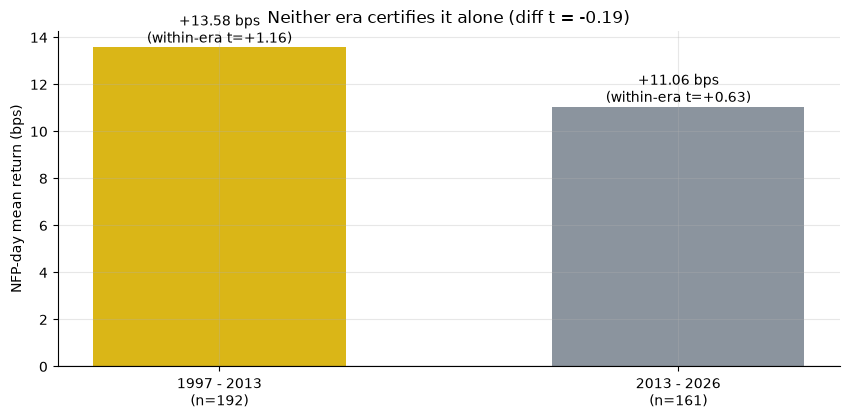

early +13.58 (t=+1.16)  late +11.06 (t=+0.63)  diff t = -0.19


In [5]:
if HAVE_REAL:
    ec = st.era_contrast(DF, '2013-01-01')
    e, l = ec['early_bps'], ec['late_bps']
    et, lt, dt = ec['welch_t_early'], ec['welch_t_late'], ec['welch_t_diff']
else:
    e, l = R['era_early'], R['era_late']
    et, lt, dt = R['era_early_t'], R['era_late_t'], R['era_diff_t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['1997 - 2013\n(n=192)','2013 - 2026\n(n=161)'], [e, l],
       color=[AMBER, GREY], width=.55)
for i,(v,t_) in enumerate([(e,et),(l,lt)]):
    ax.annotate(f'{v:+.2f} bps\n(within-era t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('NFP-day mean return (bps)')
ax.set_title(f'Neither era certifies it alone (diff t = {dt:+.2f})')
plt.tight_layout(); plt.show()
print(f'early {e:+.2f} (t={et:+.2f})  late {l:+.2f} (t={lt:+.2f})  diff t = {dt:+.2f}')

> 💡 In plain words: +13.58 bps early vs +11.06 bps late — a mild apparent decline, but neither slice is certified alone (t = +1.16 / +0.63) and the difference itself is statistically nothing (t = -0.19). No decay story to tell — there was nothing large enough to decay from.

### 4e · The third axis — the honest naive-timer cost sweep

Enter the prior close (zero look-ahead — the calendar is public months ahead), exit the release close, pay 2 × one-way costs per event.

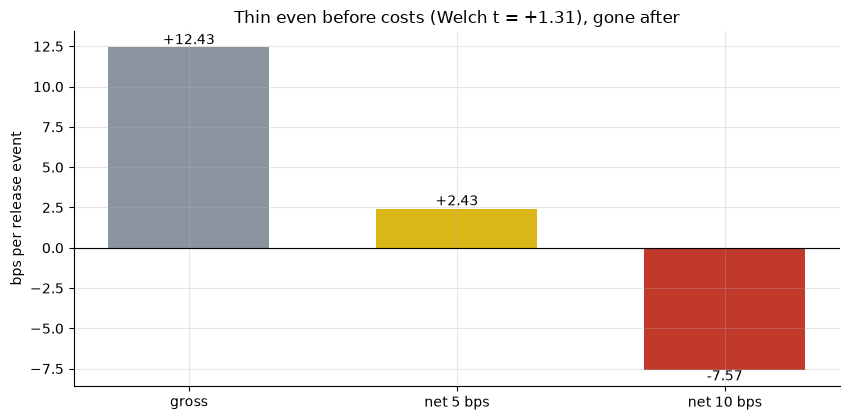

gross +12.43 -> net +2.43 (5bps) / -7.57 (10bps) bps;  hit rate 58.4%  worst day -6.0%


In [6]:
if HAVE_REAL:
    tc5 = st.timer_capture(DF, cost_bps=5.0)
    tc10 = st.timer_capture(DF, cost_bps=10.0)
    g, n5, n10 = tc5['gross_bps'], tc5['net_bps'], tc10['net_bps']
    tv, worst, hitr = tc5['welch_t'], tc5['worst_day_pct'], tc5['hit_rate']
else:
    g, n5, n10 = R['tm_gross'], R['tm_net5'], R['tm_net10']
    tv, worst, hitr = R['welch_t'], R['tm_worst'], R['tm_hit'] / 100
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['gross','net 5 bps','net 10 bps'], [g, n5, n10],
       color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([g, n5, n10]): ax.annotate(f'{v:+.2f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('bps per release event')
ax.set_title(f'Thin even before costs (Welch t = {tv:+.2f}), gone after')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f} -> net {n5:+.2f} (5bps) / {n10:+.2f} (10bps) bps;  '
      f'hit rate {hitr*100:.1f}%  worst day {worst:+.1f}%')

> 💡 In plain words: +2.43 bps net per event at 5 bps (~+0.29%/yr from twelve releases) sitting on top of an already-uncertified gross estimate (*t* = 1.31), and **-7.57 bps — negative — at 10 bps**. A 6.0% worst day is a normal bad session, not a tail event, and it alone would wipe out roughly two years of the 5-bps net edge. **H₄ not certified; Tradability = MIRAGE.**

### 4f · Faithful-engine & power control — we know the truth here

Synthetic random-walk daily-return world, scheduled pseudo-releases every 21st business day, TUNABLE planted release-day effect. The null (edge = 0) is checked over **20 seeds** — never a single stream.

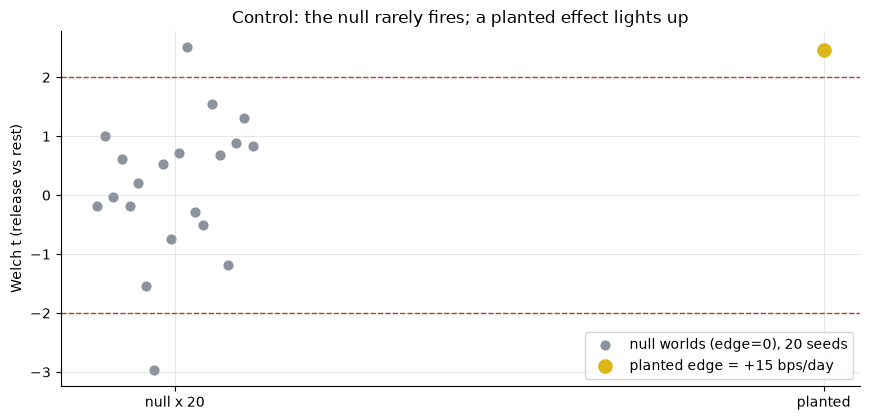

null: mean t = +0.16 (sd 1.20), |t|>=2 in 2/20 seeds  |  planted t = +2.46


In [7]:
null_ts = []
for s_ in range(20):
    close, rel = data.synthetic_world(edge=0.0, seed=643 + s_)
    null_ts.append(st.synthetic_detect(close, rel)['welch_t'])
null_ts = np.asarray(null_ts)
close, rel = data.synthetic_world(edge=0.0015, seed=643)
planted_t = st.synthetic_detect(close, rel)['welch_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted_t], color=AMBER, s=90, zorder=5,
           label='planted edge = +15 bps/day')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (release vs rest)')
ax.set_title('Control: the null rarely fires; a planted effect lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.16 (sd 1.20) and fires (2/20 seeds) at roughly the rate a two-sided *t* = 2 test should — no systematic bias in the harness. A planted +15 bps/day effect (about the real observed gap's order of magnitude) reads t = 2.46, clearing the bar — the machinery *can* detect an effect this size; the real tape's own *t* = 1.31 says it just isn't there at the certified level. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — release-day return **+12.43 bps** vs +3.37: Welch t = **1.31**, NW t = **1.31**, placebo p = **0.079** (two-sided); hit 58.4% (Wilson [53.2%, 63.4%]) vs a 54.1% baseline. A nominal pre-release drift (t = +2.07) is one uncorrected hit among seven offsets — flagged, not certified.
- **Tradability `MIRAGE`** — the naive timer nets +2.43 bps/event at 5 bps (~+0.29%/yr) and -7.57 bps at 10 bps, on top of an uncertified gross estimate, with a -6.0% worst day.
- **"Louder, not directional?" `CONFIRMED`** — realized range clears the bar (t = +2.50) while the return itself does not (t = +1.31). Scheduled news makes for a genuinely noisier morning; it does not hand you a certified direction to trade.

## 6 · Going further

- **The general object is scheduled-announcement volatility**, not a directional premium. Andersen-Bollerslev (1998) and Balduzzi-Elton-Green (2001) document the loudness half broadly; the professional expression is options straddles around the print, not a directional cash-equity timer.
- **The pre-release hint is worth its own study** — pre-registered, with a multiple-comparisons correction stated *before* the scan, on data this study hasn't touched.
- **Dedup map:** [385-jobless-claims-momentum](../../385-jobless-claims-momentum/) (weekly claims, a slow leading indicator, different series and clock), [602-macro-announcement-premium](../../602-macro-announcement-premium/) (the pooled CPI+FOMC+NFP bundle, shown there to be FOMC-driven), and [637-fomc-vol-crush](../../637-fomc-vol-crush/) (the VIX collapse on FOMC afternoons — the sibling study where *both* the loudness and the direction certify).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*